<a href="https://colab.research.google.com/github/sayu0303/CONTROLE-2025/blob/main/P5_do_zero_CONTROLE_060226.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CONTROLE DE PROCESSOS
---------------------------------

###REFAZENDO E REORGANIZANDO A PRÁTICA 5 EXECUTADA EM SALA DE AULA


##**Exemplo resolvido PARA MALHA ABERTA (tentando executar o código em um único bloco)**

In [1]:
#Instalação da biblioteca control

!pip install control -qq control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 6.6 MB/s eta 0:00:00


### **Método de Sundaresan e Krishnaswamy (1° Ordem)**

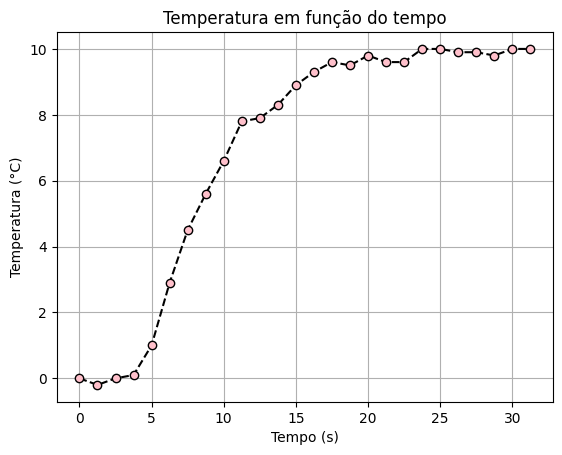

Determinação dos parâmetros para um sistema de 1ª ordem: Theta = 3.7750000000000004 e Tau = 5.862500000000001
O ganho do processo (K) calculado é: 10.0


Text(0.5, 1.0, 'Temperatura em função do tempo')

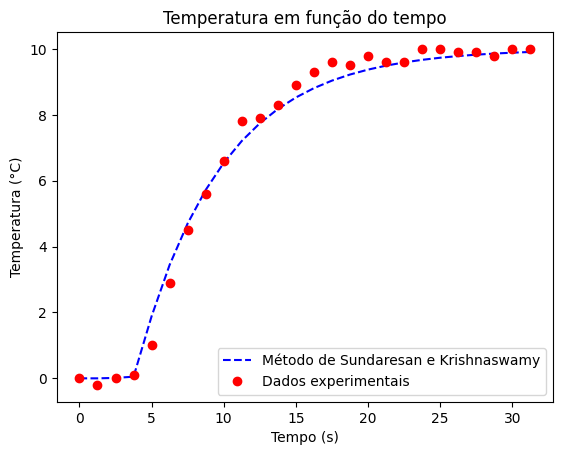

In [2]:
from matplotlib.lines import lineMarkers
#Importação das bibliotecas

import numpy as np              #Biblioteca de operações matemáticas
import matplotlib.pyplot as plt #Biblioteca para plotagem de gráficos
import control as ct            #Biblioteca para implementação de controle

#Definição dos dados de tempo e temperatura, propostas no problema

tempo = np.array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.,
       11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
       22.5 , 23.75, 25.  , 26.25, 27.5 , 28.75, 30., 31.25  ])

Temp = np.array([ 0. , -0.2, -0. ,  0.1,  1. ,  2.9,  4.5,  5.6,  6.6,  7.8,  7.9,
        8.3,  8.9,  9.3,  9.6,  9.5,  9.8,  9.6,  9.6, 10. , 10. ,  9.9,
        9.9,  9.8, 10., 10. ])

# Plotagem de um gráfico para expressar os valores de temperatura em função
# do tempo

plt.plot(tempo, Temp,linestyle = '--', color = 'black', marker = 'o', markerfacecolor = 'pink')
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')
plt.grid()
plt.show()

#APLICAÇÃO DO MÉTODO DE SUNDARESAN E KRISHNASWAY

'''
Esse método é aplicado quando trata-se de um sistema com muitos ruídos. Com isso,
o método já "pré-define" os chutes a serem feitos, no caso do exercício proposto
é em relação ao tempo, sendo t1 = 35,3% e t2 = 85,3%.

'''

#Chutes iniciais para os tempos

t1_SK = 6.25
t2_SK = 15

'''
Com a determinação dos tempos em relação ao chute "pré-definido" do método,
é possível estimar os parâmetros do método de 1ª Ordem, também definidas pelo
método.

'''

#Definição dos parâmetros theta e tau

tau_SK = 0.67*(t2_SK - t1_SK)         #Definição de theta de acordo com o método
theta_SK = (1.3*t1_SK) - (0.29*t2_SK) #Definição de tau de acordo com o método

print(f'Determinação dos parâmetros para um sistema de 1ª ordem: Theta = {theta_SK} e Tau = {tau_SK}')

#Definição do meu parâmetro K

'''
Aqui, deve ser seguido o que foi proposto pelo método para o cáculo do parâmetro K,
em um sistema de 1ª ordem. De acordo com a equação expressa a seguir.

'''

delta_ySK = Temp[-1] - Temp[0]   #Definição do meu delta y, seguindo a proposta do método, subtraindo o último termo pelo primeiro no eixo Y
delta_uSK = 1                    #Definição do meu delta u, considerando ele um degrau unitário

K_SK = delta_ySK/delta_uSK

print(f'O ganho do processo (K) calculado é: {K_SK}')

#Definição do modelo

Gdt_SK = ct.tf(*ct.pade(theta_SK, 15)) #Aproximação de padé para o atraso de tempo theta, convertendo o atraso puro em uma funçãode transferência racional
G_SK = ct.tf(K_SK,[tau_SK,1])*Gdt_SK #Definição do modelo de 1ª Ordem

#Simulação do modelo

tsim_SK, ysim_SK = ct.step_response(G_SK,T=tempo) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo

plt.plot(tsim_SK,ysim_SK, '--b', label = 'Método de Sundaresan e Krishnaswamy')
plt.plot(tempo,Temp, 'or', label = 'Dados experimentais')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')




### **Método do tempo requerido (1° Ordem)**

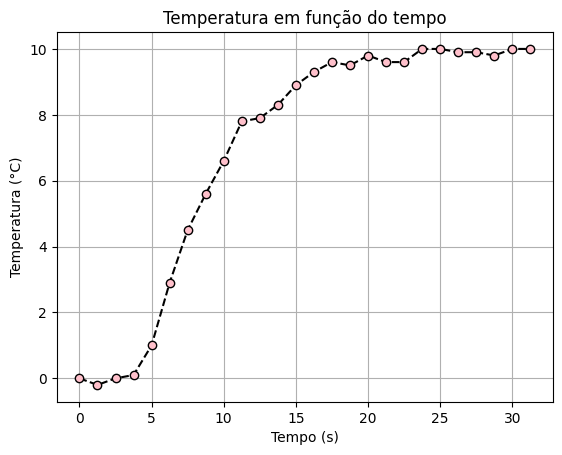

Tempo-morto: theta = 3.75; Constante de tempo; taup = 6.25
O ganho do processo (K) calculado é: 10.0


Text(0.5, 1.0, 'Temperatura em função do tempo')

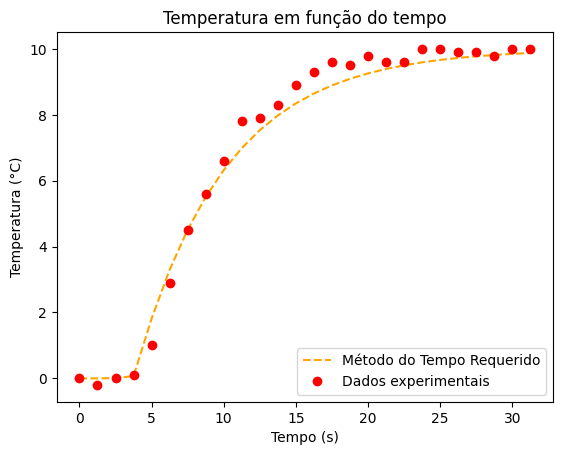

In [3]:
#Importação das bibliotecas

import numpy as np              #Biblioteca de operações matemáticas
import matplotlib.pyplot as plt #Biblioteca para plotagem de gráficos
import control as ct            #Biblioteca para implementação de controle

#Definição dos dados de tempo e temperatura, propostas no problema

tempo = np.array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.,
       11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
       22.5 , 23.75, 25.  , 26.25, 27.5 , 28.75, 30., 31.25  ])

Temp = np.array([ 0. , -0.2, -0. ,  0.1,  1. ,  2.9,  4.5,  5.6,  6.6,  7.8,  7.9,
        8.3,  8.9,  9.3,  9.6,  9.5,  9.8,  9.6,  9.6, 10. , 10. ,  9.9,
        9.9,  9.8, 10., 10. ])

# Plotagem de um gráfico para expressar os valores de temperatura em função
# do tempo

plt.plot(tempo, Temp,linestyle = '--', color = 'black', marker = 'o', markerfacecolor = 'pink')
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')
plt.grid()
plt.show()

#APLICAÇÃO DO MÉTODO DO TEMPO REQUERIDO

'''
Esse método é aplicado quando trata-se de um sistema com muitos ruídos. Com isso,
o método já "pré-define" o chute a ser feito, no caso do exercício proposto
é em relação ao tempo, sendo t = 63,2%.

'''

#Definição do theta e do tau

'''
Para esse método, foi feito a análise visual do gráfico gerado pelos dados experimentais.
Dessa forma, o theta é definido como sendo o tempo em que a temperatura permanece constante
no ínicio (tempo morto), já o tau é dado pelo tempo com 63,2% da temperatura total.

'''

theta_TR = 3.75          #Tempo em que a temperatura se manteve constante no ínicio
tau_TR = 10.0 - theta_TR #Tempo para atingir 63,2% de temperatura - theta

print(f'Tempo-morto: theta = {theta_TR}; Constante de tempo; taup = {tau_TR}')

#Definição do parâmetro K

delta_yTR = Temp[-1] - Temp[0] #Subtração da última temperatura com a primeira
delta_uTR = 1                  #Degrau unitário

K_TR = delta_yTR/delta_uTR

print(f'O ganho do processo (K) calculado é: {K_TR}')

#Definição do modelo

Gdt_TR = ct.tf(*ct.pade(theta_TR, 15)) #Aproximação de padé para o atraso de tempo theta, convertendo o atraso puro em uma funçãode transferência racional
G_TR = ct.tf(K_TR,[tau_TR,1])*Gdt_TR      #Definição do modelo de 1ª Ordem

#Simulação do modelo

tsim_TR, ysim_TR = ct.step_response(G_TR,T=tempo) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo

plt.plot(tsim_TR,ysim_TR, linestyle = '--',color = 'orange', label = 'Método do Tempo Requerido')
#plt.plot(tsim_SK,ysim_SK, '--b', label = 'Método de Sundaresan e Krishnaswamy')
plt.plot(tempo,Temp, 'or', label = 'Dados experimentais')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')




### **Método de Smith (2ª Ordem)**

Relação de tempos: para t a 20%: 1.5499999999999998; para t a 60%: 5.25; fator de análise gráfica do t20/t60: 0.2952380952380952
Determinação dos parâmetros para um sistema de 2ª ordem: Psi = 2.1 e Tau = 1.5
Tau1 = 0.38007220310709183 e Tau2 = 5.919927796892905
O ganho do processo (K) calculado é: 10.0


Text(0.5, 1.0, 'Temperatura em função do tempo')

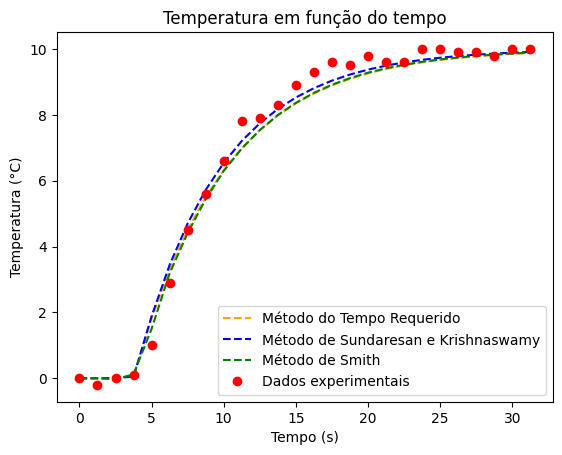

In [4]:
#Importação das bibliotecas

import numpy as np              #Biblioteca de operações matemáticas
import matplotlib.pyplot as plt #Biblioteca para plotagem de gráficos
import control as ct            #Biblioteca para implementação de controle

#Definição dos dados de tempo e temperatura, propostas no problema

tempo = np.array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.,
       11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
       22.5 , 23.75, 25.  , 26.25, 27.5 , 28.75, 30., 31.25  ])

Temp = np.array([ 0. , -0.2, -0. ,  0.1,  1. ,  2.9,  4.5,  5.6,  6.6,  7.8,  7.9,
        8.3,  8.9,  9.3,  9.6,  9.5,  9.8,  9.6,  9.6, 10. , 10. ,  9.9,
        9.9,  9.8, 10., 10. ])

# Plotagem de um gráfico para expressar os valores de temperatura em função
# do tempo

# plt.plot(tempo, Temp,linestyle = '--', color = 'black', marker = 'o', markerfacecolor = 'pink')
# plt.xlabel('Tempo (s)')
# plt.ylabel('Temperatura (°C)')
# plt.title('Temperatura em função do tempo')
# plt.grid()
# plt.show()

#APLICAÇÃO DO MÉTODO DE SMITH

'''
Esse método é aplicado para sistemas de 2ª Ordem. Com isso,o método já
"pré-define" os chutes a serem feitos, no caso do exercício proposto é em
relação ao tempo, sendo t1 = 20% e t2 = 60%.

'''

#Chutes iniciais para o tempo (Obtidos a partir de analise gráfica)

t20 = 5.3
t60 = 9

#Redefinição dos tempos encontrados, para deixa-los desconsiderando o tempo morto

t20_SM = t20 - tempo[3]
t60_SM = t60 - tempo[3]

t_analise_SM = t20_SM/t60_SM

print(f'Relação de tempos: para t a 20%: {t20_SM}; para t a 60%: {t60_SM}; fator de análise gráfica do t20/t60: {t_analise_SM}')

'''
Com a determinação dos tempos em relação ao chute "pré-definido" do método,
é possível estimar os parâmetros do método analisando o gráfico analítico
do próprio método. Com isso, é possivel obter tau e psi, que serão uteis para
a execução do método de 2ª Ordem.
'''
#Definição dos parâmetros tau e psi

psi_SM = 2.1
tau_SM = t60_SM/3.5

print(f'Determinação dos parâmetros para um sistema de 2ª ordem: Psi = {psi_SM} e Tau = {tau_SM}')

'''
Como o psi é maior que 1, o método sugere que tau1 e tau2 sejam calculados em função
de psi e tau. Expressado na equação a seguir.

'''

#Definição de tau1 e tau2

tau1_SM = tau_SM/(psi_SM + np.sqrt(psi_SM**2 - 1))
tau2_SM = tau_SM/(psi_SM - np.sqrt(psi_SM**2 - 1))

print(f'Tau1 = {tau1_SM} e Tau2 = {tau2_SM}')

#Definição do parâmetro K

delta_ySM = Temp[-1] - Temp[0] #Subtração da última temperatura com a primeira
delta_uSM = 1                  #Degrau unitário

K_SM = delta_ySM/delta_uSM

print(f'O ganho do processo (K) calculado é: {K_SM}')

'''
Tau1 é muito menor que tau2, significa que o sistema até é de 2ª Ordem, mas
se comporta como se fosse de 1ª Ordem. Com isso, utiliza-se a Regra da Metade
de Skogestad associada ao método para aplicar ao modelo.


'''

#Definição do modelo

Gdt_SM = ct.tf(*ct.pade(tempo[3]+tau1_SM/2, 6 ,3 ))    #Utilizanod a Regra de Skogestad, substitui a dinâmica rápida por um atraso equivalente
G_SM = ct.tf(K_SM,[tau2_SM + tau1_SM/2,1])*Gdt_SM      #Definição do modelo de 1ª Ordem com atraso

#Simulação do modelo

tsim_SM, ysim_SM = ct.step_response(G_SM,T=tempo) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo

plt.plot(tsim_TR,ysim_TR, linestyle = '--',color = 'orange', label = 'Método do Tempo Requerido')
plt.plot(tsim_SK,ysim_SK, '--b', label = 'Método de Sundaresan e Krishnaswamy')
plt.plot(tsim_SM,ysim_SM, '--g', label = 'Método de Smith')
plt.plot(tempo,Temp, 'or', label = 'Dados experimentais')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')


#**ATIVIDADE PROPOSTA**

**Método de Smith (transformado para 1ª ordem pela Regra da Metade do Skogestad)**

Relação de tempos: para t a 20%: 1.5; para t a 60%: 4.5; fator de análise gráfica do t20/t60: 0.3333333333333333
Determinação dos parâmetros para um sistema de 2ª ordem: Psi = 1.7 e Tau = 1.6071428571428572
Tau1 = 0.5226867185034343 e Tau2 = 4.941598995782278


Text(0.5, 1.0, 'Temperatura em função do tempo')

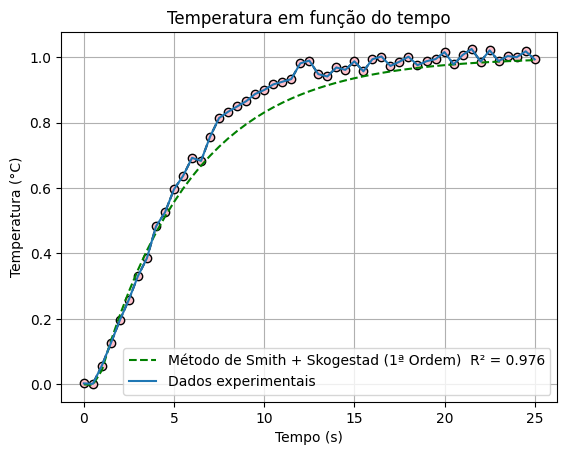

In [5]:
#Definição das bibliotecas utilizadas

import numpy as np
import matplotlib.pyplot as plt
import control as ct
from sklearn.metrics import r2_score

#Definição dos dados de tempo e concentração, propostas no exercício

# Dados experimentais
t_2 = t = np.arange(0,25.5,0.5) #Intervalo de 0 a 25, caminhando de 0.5 segundos
y_CO2 = np.array(
      [0.00309765, 0.00179671, 0.05736463, 0.1259297 , 0.1965255 ,
       0.25928347, 0.33100036, 0.38557044, 0.48261651, 0.52532396,
       0.59605249, 0.63664968, 0.692138  , 0.682736  , 0.75676213,
       0.81374694, 0.8329348 , 0.84901645, 0.86510134, 0.88727795,
       0.89927448, 0.91638715, 0.92440394, 0.93261136, 0.9807045 ,
       0.98915155, 0.9478411 , 0.94059148, 0.96817854, 0.96085958,
       0.98704477, 0.95626661, 0.99332458, 1.00163399, 0.9728743 ,
       0.98581019, 1.00116753, 0.97514747, 0.98721072, 0.99374204,
       1.0151221 , 0.97736421, 1.00618801, 1.02481627, 0.98613209,
       1.02047745, 0.98770272, 1.00294645, 0.99945405, 1.01756078,
       0.99274144])

# Plotagem3 dos dados
plt.plot(t_2, y_CO2, marker='o', markerfacecolor='pink', markeredgecolor='black',
         markeredgewidth=1, linestyle='--', color='black')
plt.xlabel("Tempo $t$ [min]")
plt.ylabel(r"$CO_2$ $y$ [adim.]")
plt.grid()

#APLICAÇÃO DO MÉTODO DE SMITH

#Chute iniciais para o tempo

t20 = 2.0
t60 = 5.0

#Redefinição dos tempos encontrados, para deixa-los desconsiderando o tempo morto

t20_SM = t20 - t[1]
t60_SM = t60 - t[1]

t_analise_SM = t20_SM/t60_SM

print(f'Relação de tempos: para t a 20%: {t20_SM}; para t a 60%: {t60_SM}; fator de análise gráfica do t20/t60: {t_analise_SM}')

#Definição dos parâmetros tau e psi (análise gráfica do método)

psi_SM = 1.7
tau_SM = t60_SM/2.8

print(f'Determinação dos parâmetros para um sistema de 2ª ordem: Psi = {psi_SM} e Tau = {tau_SM}')

'''
Como o psi é maior que 1, o método sugere que tau1 e tau2 sejam calculados em função
de psi e tau. Expressado na equação a seguir.

'''

#Definição de tau1 e tau2

tau1_SM = tau_SM/(psi_SM + np.sqrt(psi_SM**2 - 1))
tau2_SM = tau_SM/(psi_SM - np.sqrt(psi_SM**2 - 1))

print(f'Tau1 = {tau1_SM} e Tau2 = {tau2_SM}')

#Definição do parâmetro K

K_SM = 1 #O exercício definiu que K=1

Gdt_SM = ct.tf(*ct.pade(t[1]+tau1_SM/2, 5 ,3 ))    #Utilizanod a Regra de Skogestad, substitui a dinâmica rápida por um atraso equivalente
G_SM = ct.tf(K_SM,[tau2_SM + tau1_SM/2,1])*Gdt_SM      #Definição do modelo de 1ª Ordem com atraso

#Simulação do modelo

tsim_SM, ysim_SM = ct.step_response(G_SM,T=t) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo

plt.plot(tsim_SM,ysim_SM, '--g', label = f'Método de Smith + Skogestad (1ª Ordem)  R² = {r2_score(ysim_SM,y_CO2 ):1.3f}')
plt.plot(t,y_CO2, label = 'Dados experimentais')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')

**Método de Smith (2ª ordem)**

Relação de tempos: para t a 20%: 1.5; para t a 60%: 4.5; fator de análise gráfica do t20/t60: 0.3333333333333333
Determinação dos parâmetros para um sistema de 2ª ordem: Psi = 1.7 e Tau = 1.6071428571428572


Text(0.5, 1.0, 'Temperatura em função do tempo')

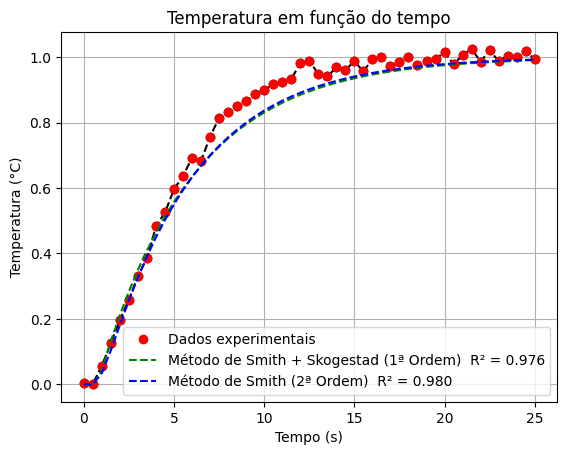

In [6]:
#Definição das bibliotecas utilizadas

import numpy as np
import matplotlib.pyplot as plt
import control as ct
from sklearn.metrics import r2_score

#Definição dos dados de tempo e concentração, propostas no exercício

# Dados experimentais
t_2 = t = np.arange(0,25.5,0.5) #Intervalo de 0 a 25, caminhando de 0.5 segundos
y_CO2 = np.array(
      [0.00309765, 0.00179671, 0.05736463, 0.1259297 , 0.1965255 ,
       0.25928347, 0.33100036, 0.38557044, 0.48261651, 0.52532396,
       0.59605249, 0.63664968, 0.692138  , 0.682736  , 0.75676213,
       0.81374694, 0.8329348 , 0.84901645, 0.86510134, 0.88727795,
       0.89927448, 0.91638715, 0.92440394, 0.93261136, 0.9807045 ,
       0.98915155, 0.9478411 , 0.94059148, 0.96817854, 0.96085958,
       0.98704477, 0.95626661, 0.99332458, 1.00163399, 0.9728743 ,
       0.98581019, 1.00116753, 0.97514747, 0.98721072, 0.99374204,
       1.0151221 , 0.97736421, 1.00618801, 1.02481627, 0.98613209,
       1.02047745, 0.98770272, 1.00294645, 0.99945405, 1.01756078,
       0.99274144])

# Plotagem dos dados
plt.plot(t_2, y_CO2, marker='o', markerfacecolor='pink', markeredgecolor='black',
         markeredgewidth=1, linestyle='--', color='black')
plt.xlabel("Tempo $t$ [min]")
plt.ylabel(r"$CO_2$ $y$ [adim.]")
plt.grid()

#APLICAÇÃO DO MÉTODO DE SMITH

#Chute iniciais para o tempo

t20 = 2.0
t60 = 5.0

#Redefinição dos tempos encontrados, para deixa-los desconsiderando o tempo morto

t20_SM2 = t20 - t[1]
t60_SM2 = t60 - t[1]

t_analise_SM2 = t20_SM2/t60_SM2

print(f'Relação de tempos: para t a 20%: {t20_SM2}; para t a 60%: {t60_SM2}; fator de análise gráfica do t20/t60: {t_analise_SM}')

#Definição dos parâmetros tau e psi (análise gráfica do método)

psi_SM2 = 1.7
tau_SM2 = t60_SM2/2.8

print(f'Determinação dos parâmetros para um sistema de 2ª ordem: Psi = {psi_SM2} e Tau = {tau_SM2}')

#Definição do parâmetro K

K_SM = 1 #O exercício definiu que K=1

Gdt_SM2 = ct.tf(*ct.pade(t[1], 5 ,3 ))    #Utilizanod a Regra de Skogestad, substitui a dinâmica rápida por um atraso equivalente
G_SM2 = ct.tf(K_SM,[tau_SM2**2,2*psi_SM2*tau_SM2,1])*Gdt_SM2      #Definição do modelo de 1ª Ordem com atraso

#Simulação do modelo

tsim_SM2, ysim_SM2 = ct.step_response(G_SM2,T=t) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo
plt.plot(t,y_CO2,'or', label = 'Dados experimentais')
plt.plot(tsim_SM,ysim_SM, '--g', label = f'Método de Smith + Skogestad (1ª Ordem)  R² = {r2_score(ysim_SM,y_CO2 ):1.3f}')
plt.plot(tsim_SM2,ysim_SM2, '--b', label = f'Método de Smith (2ª Ordem)  R² = {r2_score(ysim_SM2,y_CO2 ):1.3f}')

plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')


**Método do tempo requerido de saída a 63,2%  (1ª ordem)**

Tempo-morto: theta = 3.75; Constante de tempo; taup = 6.25
O ganho do processo (K) calculado é: 1


Text(0.5, 1.0, 'Temperatura em função do tempo')

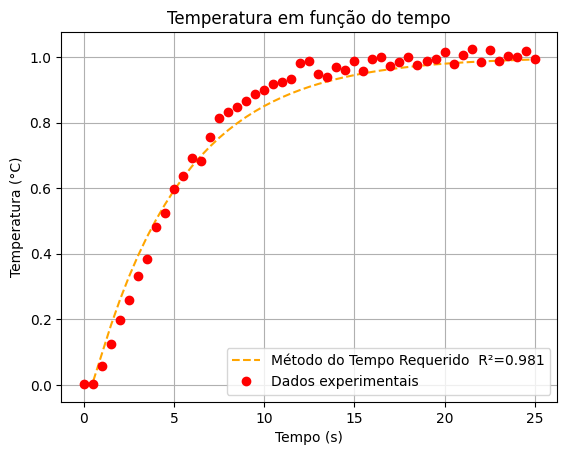

In [7]:
#Definição das bibliotecas utilizadas

import numpy as np
import matplotlib.pyplot as plt
import control as ct
from sklearn.metrics import r2_score

#Definição dos dados de tempo e concentração, propostas no exercício

# Dados experimentais
t_2 = t = np.arange(0,25.5,0.5) #Intervalo de 0 a 25, caminhando de 0.5 segundos
y_CO2 = np.array(
      [0.00309765, 0.00179671, 0.05736463, 0.1259297 , 0.1965255 ,
       0.25928347, 0.33100036, 0.38557044, 0.48261651, 0.52532396,
       0.59605249, 0.63664968, 0.692138  , 0.682736  , 0.75676213,
       0.81374694, 0.8329348 , 0.84901645, 0.86510134, 0.88727795,
       0.89927448, 0.91638715, 0.92440394, 0.93261136, 0.9807045 ,
       0.98915155, 0.9478411 , 0.94059148, 0.96817854, 0.96085958,
       0.98704477, 0.95626661, 0.99332458, 1.00163399, 0.9728743 ,
       0.98581019, 1.00116753, 0.97514747, 0.98721072, 0.99374204,
       1.0151221 , 0.97736421, 1.00618801, 1.02481627, 0.98613209,
       1.02047745, 0.98770272, 1.00294645, 0.99945405, 1.01756078,
       0.99274144])

# Plotagem dos dados
#plt.plot(t_2, y_CO2, marker='o', markerfacecolor='pink', markeredgecolor='black',
        # markeredgewidth=1, linestyle='--', color='black')
plt.xlabel("Tempo $t$ [min]")
plt.ylabel(r"$CO_2$ $y$ [adim.]")
plt.grid()

#Chutes iniciais

theta_TR2 = t[1]           #Tempo em que a temperatura se manteve constante no ínicio
tau_TR2 = t[11] - theta_TR2 #Tempo para atingir 63,2% de temperatura - theta

print(f'Tempo-morto: theta = {theta_TR}; Constante de tempo; taup = {tau_TR}')

#Definição do parâmetro K

K_TR2 = 1 #Definido pelo exercício

print(f'O ganho do processo (K) calculado é: {K_TR2}')

#Definição do modelo

Gdt_TR2 = ct.tf(*ct.pade(theta_TR2, 2))    #Aproximação de padé para o atraso de tempo theta, convertendo o atraso puro em uma funçãode transferência racional
G_TR2 = ct.tf(K_TR2,[tau_TR2,1])*Gdt_TR2      #Definição do modelo de 1ª Ordem

#Simulação do modelo

tsim_TR2, ysim_TR2 = ct.step_response(G_TR2,T=t) #Cálculo da resposta ao degrau unitário do sistema, utilizando o vetor de tempo definido

#Plotagem dos dados gerados pelo modelo

plt.plot(tsim_TR2,ysim_TR2, linestyle = '--',color = 'orange', label = f'Método do Tempo Requerido  R²={r2_score(ysim_TR2,y_CO2):1.3}')
#plt.plot(tsim_SK,ysim_SK, '--b', label = 'Método de Sundaresan e Krishnaswamy')
plt.plot(t,y_CO2, 'or', label = 'Dados experimentais')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')

In [8]:
t[11]

np.float64(5.5)